<a href="https://colab.research.google.com/github/winzepz/Artificial-Intelligence-and-Machine-Learning/blob/main/DP_W01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Exercise - 1:

1. Read and display the image.

In [ ]:
img_path = '/content/drive/MyDrive/Colab Notebooks/AI and Machine Learning/lenna.jpg'
img = Image.open(img_path)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


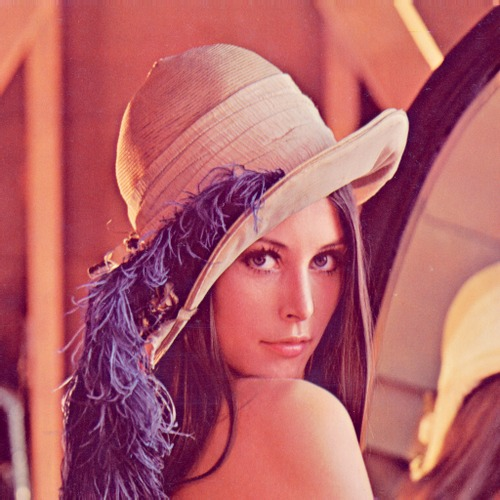

In [ ]:
display(img)

2. Display only the top left corner of 100x100 pixels.

In [ ]:
img_array = np.array(img)

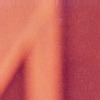

In [ ]:
cropped_image_array = img_array[0:100, 0:100]
cropped_img = Image.fromarray(cropped_image_array)
display(cropped_img)

3. Show the three color channels (R, G, B).

In [ ]:
r, g, b = img.split()

In [ ]:
r_channel = img_array[:, :, 0] # Red channel
g_channel = img_array[:, :, 1] # Green channel
b_channel = img_array[:, :, 2] # Blue channel

array([[138, 139, 136, ..., 146, 133, 104],
       [139, 140, 136, ..., 145, 129, 101],
       [138, 139, 135, ..., 148, 133, 102],
       ...,
       [ 13,  12,  18, ...,  66,  65,  64],
       [ 13,  13,  21, ...,  67,  69,  69],
       [ 13,  15,  24, ...,  68,  71,  73]], dtype=uint8)
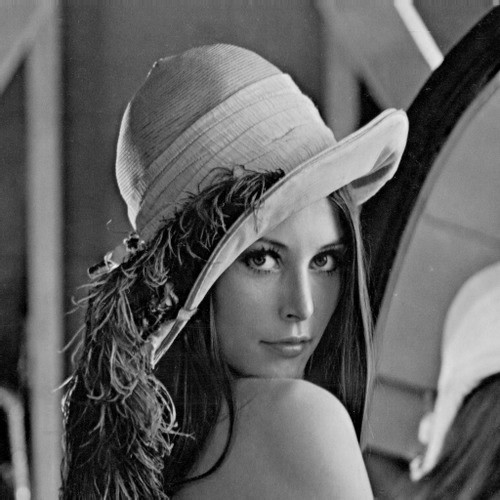

In [ ]:
# print ( g_channel )
display ( g_channel )

array([[226, 227, 226, ..., 234, 225, 197],
       [227, 228, 226, ..., 235, 221, 194],
       [226, 227, 225, ..., 240, 225, 197],
       ...,
       [ 80,  80,  93, ..., 176, 176, 174],
       [ 80,  81,  96, ..., 179, 181, 181],
       [ 80,  83,  99, ..., 180, 183, 185]], dtype=uint8)
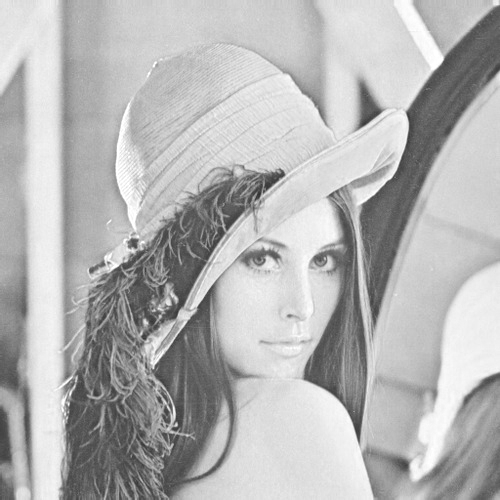

In [ ]:
display ( r_channel )

array([[128, 129, 127, ..., 122, 112,  86],
       [129, 130, 127, ..., 121, 108,  83],
       [126, 127, 124, ..., 125, 112,  82],
       ...,
       [ 54,  51,  57, ...,  79,  81,  77],
       [ 54,  52,  60, ...,  79,  83,  81],
       [ 54,  54,  63, ...,  80,  83,  85]], dtype=uint8)
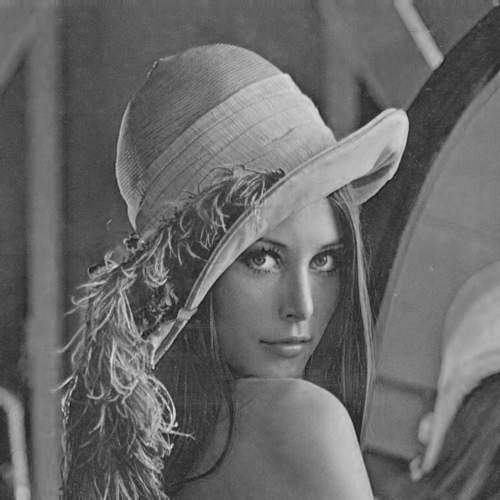

In [ ]:
display ( b_channel )

In [ ]:
image = np.zeros((300, 300), dtype=np.uint8)

In [ ]:
image[0:100, 0:100] = 210

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

In [ ]:
img_array[0:100, 0:100] = 210
result = Image.fromarray(img_array)

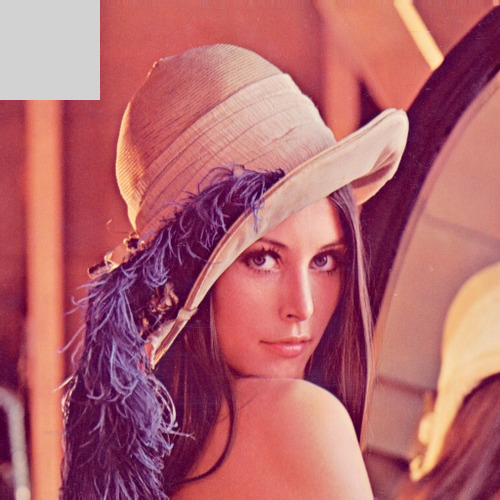

In [ ]:
display(result)

# 2.2 Exercise - 2:

1. Load and display a grayscale image.

In [ ]:
img_path = '/content/drive/MyDrive/Colab Notebooks/AI and Machine Learning/image.jpeg'
img = Image.open(img_path).convert("L")
img_array = np.array(img)

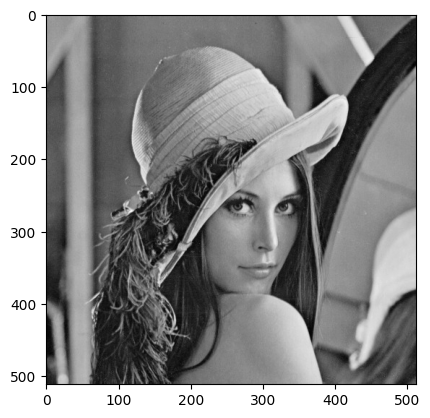

In [ ]:
plt.imshow(img, cmap="gray")

2. Extract and display the middle section of the image (150 pixels).

In [ ]:
width, height = img.size
print(f"width {width} & height {height}")

width 512 & height 512


In [ ]:
center_y, center_x = height // 2 , width // 2
print(f"Center width {center_x} & Center Height {center_y}")

Center width 256 & Center Height 256


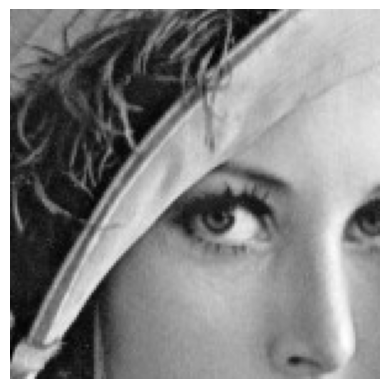

In [ ]:
center_150_section = img_array[center_y - 75: center_y + 75, center_x- 75: center_x + 75]

plt.imshow(center_150_section, cmap="gray")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

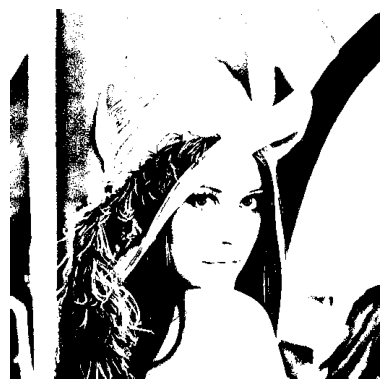

In [ ]:
binary_img = np.where(img_array < 100 , 0, 255)
plt.imshow(binary_img, cmap="gray")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

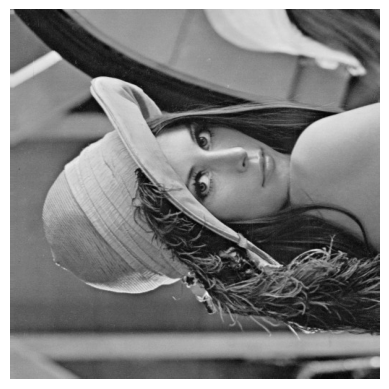

In [ ]:
ninty_degree_rotate = img.rotate(90)
plt.imshow(ninty_degree_rotate, cmap="gray")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

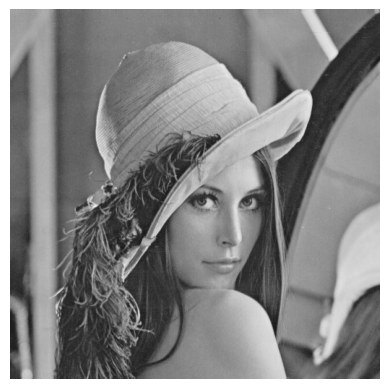

In [ ]:
grey_to_rbg_image = np.stack((img_array,)*3, axis=-1)
plt.imshow(grey_to_rbg_image)
plt.axis("off")
plt.show()

# 3 Image Compression and Decompression using PCA.

1. Load and Prepare Data:

In [ ]:
img_path = '/content/drive/MyDrive/Colab Notebooks/AI and Machine Learning/image.jpeg'
img = Image.open(img_path).convert("L")
img_array = np.array(img)

In [ ]:
data = img_array . reshape ( height , width )
mean = np.mean(data, axis=0)

In [ ]:
centered_data = data - mean

In [ ]:
# This step helps identify important patterns in the image.
cov_matrix = np.cov(centered_data, rowvar = False)

2. Eigen Decomposition and Identifying Principal Components:

In [ ]:
eigenvalues , eigenvectors = np.linalg.eigh( cov_matrix )

In [ ]:
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors [: , sorted_indices ]

In [ ]:
variance_ratio = eigenvalues / np.sum(eigenvalues)

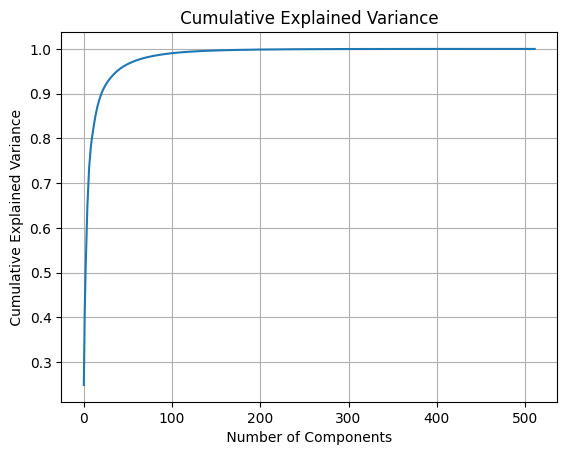

In [ ]:
plt.plot(np.cumsum(variance_ratio))
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

3. Reconstruction and Experiment:

In [ ]:
k = 1000
components = eigenvectors[:, :k]

### Explanation of Decompression Difference:

The Principal Component Analysis (PCA) algorithm aims to reduce the dimensionality of the data while retaining as much variance as possible. When you choose a small number of components (represented by `k`), you are essentially keeping only the `k` most significant patterns (eigenvectors) that explain the majority of the variance in the original image.

If `k` is too small, the reconstructed image will appear significantly different from the original because a lot of the finer details and less dominant patterns (which contribute to visual fidelity) were discarded during the compression phase. The `k=100` components chosen earlier might not be sufficient to capture enough detail for a high-quality reconstruction of a 512x512 image.

To achieve a better-quality decompressed image, you generally need to increase the value of `k`. You can use the 'Cumulative Explained Variance' plot to guide this choice. For example, selecting a `k` that corresponds to 90% or 95% of the cumulative explained variance will likely result in a much better reconstruction.

In [ ]:
compressed_data = np.dot( centered_data , components )

In [ ]:
decompressed_data = np.dot ( compressed_data , components . T ) + mean

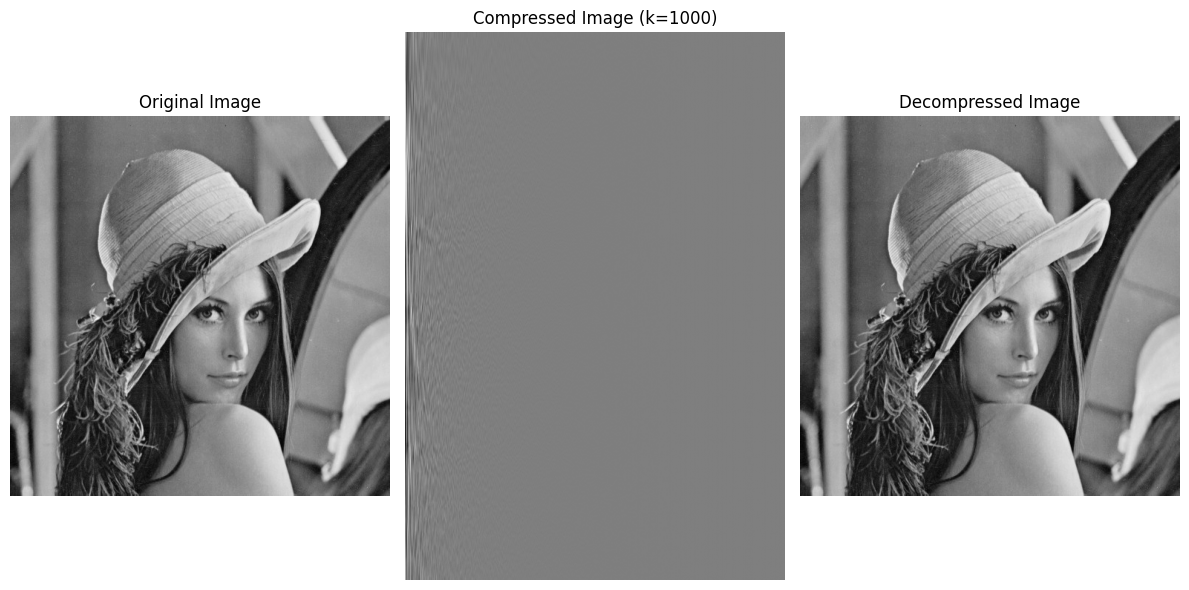

In [ ]:
# Plotting the images
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Compressed Representation
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")

# Decompressed Image
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()
plt.show()